# LSTM Model

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import sys
from pathlib import Path
import pickle
import warnings
warnings.filterwarnings('ignore')

# Add src to path
sys.path.append(str(Path('..').resolve()))

from src.utils.paths import PROCESSED_DIR, RESULTS_DIR, setup_plotting, ensure_dirs
from src.data.preprocessing import prepare_lstm_data
from src.models.rnn import LSTMModel
from src.training.rnn import train_rnn_with_cv

setup_plotting()
ensure_dirs()

# Set random seeds
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

## Load Datasets

In [2]:
dataset_A = pd.read_csv(PROCESSED_DIR / 'dataset_A_full.csv')
dataset_B = pd.read_csv(PROCESSED_DIR / 'dataset_B_metabolomics.csv')
dataset_C = pd.read_csv(PROCESSED_DIR / 'dataset_C_transcriptomics.csv')

print("Dataset shapes:")
print(f"  A (Full): {dataset_A.shape}")
print(f"  B (Metabolomics): {dataset_B.shape}")
print(f"  C (Transcriptomics): {dataset_C.shape}")

Dataset shapes:
  A (Full): (33, 1176)
  B (Metabolomics): (79, 206)
  C (Transcriptomics): (31, 212)


In [3]:

X_A, y_A, features_A = prepare_lstm_data(dataset_A, "Dataset A")
X_B, y_B, features_B = prepare_lstm_data(dataset_B, "Dataset B")
X_C, y_C, features_C = prepare_lstm_data(dataset_C, "Dataset C")


Dataset A:
  Samples: 33
  Common features: 582
  Temporal shape: (33, 2, 582) (samples, timesteps, features)

Dataset B:
  Samples: 79
  Common features: 97
  Temporal shape: (79, 2, 97) (samples, timesteps, features)

Dataset C:
  Samples: 31
  Common features: 100
  Temporal shape: (31, 2, 100) (samples, timesteps, features)


## Train on All Datasets

In [4]:
print("="*60)
print("DATASET A: Full")
print("="*60)
results_A = train_rnn_with_cv(LSTMModel, X_A, y_A, features_A, hidden_dim=64, num_layers=2, 
                               dropout=0.4, lr=0.001, epochs=350)

print("\n" + "="*60)
print("DATASET B: Metabolomics")
print("="*60)
results_B = train_rnn_with_cv(LSTMModel, X_B, y_B, features_B, hidden_dim=64, num_layers=2,
                               dropout=0.4, lr=0.001, epochs=350)

print("\n" + "="*60)
print("DATASET C: Transcriptomics")
print("="*60)
results_C = train_rnn_with_cv(LSTMModel, X_C, y_C, features_C, hidden_dim=64, num_layers=2, 
                               dropout=0.4, lr=0.001, epochs=350)

DATASET A: Full
Using device: cuda
Training 5-fold CV (Imputation & Scaling inside folds)...


  Fold 1: R²=-0.679, RMSE=3.774, MAE=2.867


  Fold 2: R²=0.243, RMSE=4.740, MAE=3.912


  Fold 3: R²=0.046, RMSE=4.217, MAE=3.732


  Fold 4: R²=-0.846, RMSE=6.013, MAE=4.274


...

  Fold 1: R²=0.413, RMSE=3.663, MAE=2.424


  Fold 2: R²=0.714, RMSE=2.100, MAE=1.834


  Fold 3: R²=0.464, RMSE=2.793, MAE=2.412


  Fold 4: R²=0.027, RMSE=2.097, MAE=1.573


  Fold 5: R²=0.684, RMSE=3.169, MAE=2.446

R² = 0.461 ± 0.276


## Results Summary

In [5]:
summary = pd.DataFrame([
    {'Dataset': 'A (Full)', 'N': len(X_A), 'Features': X_A.shape[2],
     'R²': f"{results_A['mean_r2']:.3f} ± {results_A['std_r2']:.3f}",
     'RMSE': f"{results_A['mean_rmse']:.3f} ± {results_A['std_rmse']:.3f}",
     'MAE': f"{results_A['mean_mae']:.3f} ± {results_A['std_mae']:.3f}"},
    {'Dataset': 'B (Metabolomics)', 'N': len(X_B), 'Features': X_B.shape[2],
     'R²': f"{results_B['mean_r2']:.3f} ± {results_B['std_r2']:.3f}",
     'RMSE': f"{results_B['mean_rmse']:.3f} ± {results_B['std_rmse']:.3f}",
     'MAE': f"{results_B['mean_mae']:.3f} ± {results_B['std_mae']:.3f}"},
    {'Dataset': 'C (Transcriptomics)', 'N': len(X_C), 'Features': X_C.shape[2],
     'R²': f"{results_C['mean_r2']:.3f} ± {results_C['std_r2']:.3f}",
     'RMSE': f"{results_C['mean_rmse']:.3f} ± {results_C['std_rmse']:.3f}",
     'MAE': f"{results_C['mean_mae']:.3f} ± {results_C['std_mae']:.3f}"}
])

print("\nRESULTS SUMMARY:")
print(summary.to_string(index=False))
summary.to_csv(RESULTS_DIR / 'lstm_summary.csv', index=False)


RESULTS SUMMARY:
            Dataset  N  Features             R²          RMSE           MAE
           A (Full) 33       582 -0.307 ± 0.463 4.171 ± 1.426 3.290 ± 1.045
   B (Metabolomics) 79        97  0.043 ± 0.350 3.770 ± 0.846 3.214 ± 0.595
C (Transcriptomics) 31       100  0.461 ± 0.276 2.764 ± 0.682 2.138 ± 0.407


## Visualizations

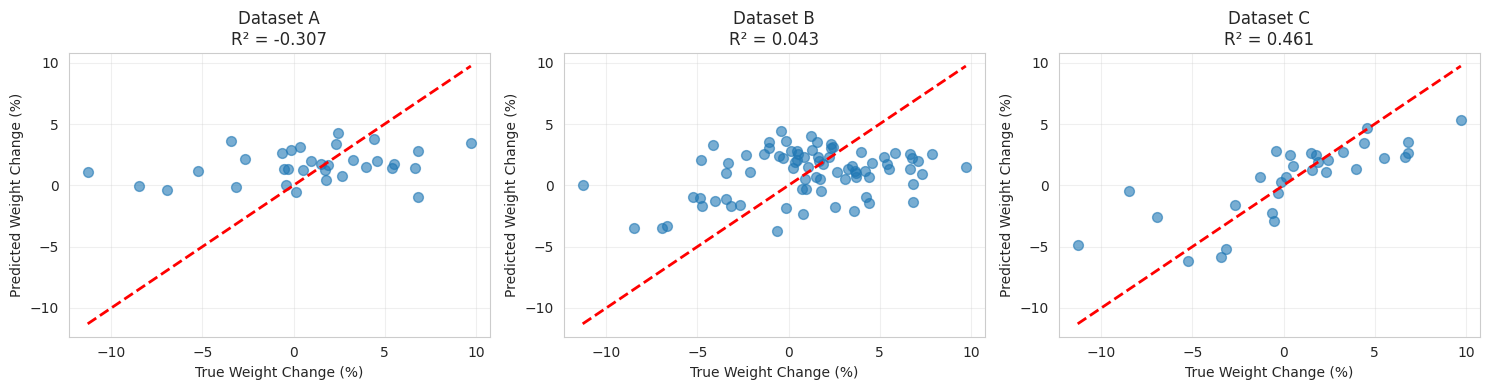

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, results, name in zip(axes, [results_A, results_B, results_C], ['Dataset A', 'Dataset B', 'Dataset C']):
    ax.scatter(results['y_true'], results['y_pred'], alpha=0.6, s=50)
    min_val = min(results['y_true'].min(), results['y_pred'].min())
    max_val = max(results['y_true'].max(), results['y_pred'].max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
    ax.set_xlabel('True Weight Change (%)')
    ax.set_ylabel('Predicted Weight Change (%)')
    ax.set_title(f'{name}\nR² = {results["mean_r2"]:.3f}')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'lstm_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

## Save Results

In [7]:
lstm_results = {'dataset_A': results_A, 'dataset_B': results_B, 'dataset_C': results_C, 'summary': summary}
with open(RESULTS_DIR / 'lstm_results.pkl', 'wb') as f:
    pickle.dump(lstm_results, f)
print("Results saved to", RESULTS_DIR)

Results saved to /home/bendavison/PycharmProjects/msc_dissertation/results
